[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ronsong1234/GrandQC_IDC-Validation/blob/main/notebooks/01_idc_experiment.ipynb)


# Capstone — IDC DICOM → Native-Magnification OME-TIFF + GrandQC QC

Standalone experiment notebook. Derived from `grandqc_slide_quality_with_idc_1.ipynb`
but **not connected to any git repository** — there is no Colab badge and no
`git pull` of this notebook; it is self-contained and Colab-compatible.

**What changed vs. the source notebook:** a new **Part 3.4** converts the IDC DICOM
series into **pyramidal OME-TIFF at native magnification**, injects the DICOM
total-pixel-matrix origin as a `pyvips` canvas shift, and emits QA tiles with
`pyvips.dzsave`. Parts 1–3 and 4–7 are carried over unchanged: GrandQC still reads
the DICOM series directly, so the conversion is additive and does not perturb the
QC pipeline.


## Read this first — two premises worth correcting

Both were checked against this notebook and against the five downloaded TCGA-BRCA
series before Part 3.4 was written.

**1. There was no DICOM→TIFF conversion cell to refactor.** The source notebook never
produced a TIFF. It feeds the DICOM series *directly* to GrandQC through the
`wsidicom_slide.py` reader in the `fedorov/grandqc` fork (branch `idc-dicom-wsidicom`).
A search of all 53 cells finds no `pyvips`, no `dzsave`, no `np.pad`, no `OME`, and no
`.tif` writing anywhere. The PIL-downsample-and-numpy-pad code that the brief describes
is real, but it lives in the **Part 7 boundary-anchored edge-tiling cell**, where it
operates on *model input patches at MPP 1.5* — it is inference-time preprocessing, not
a conversion step, and it never writes an image file. So Part 3.4 below is **new code**,
not a rewrite.

**2. The optical offsets are all exactly zero in this data.** Every one of the 20
DICOM instances across all five slides reports:

```
TotalPixelMatrixOriginSequence[0].XOffsetInSlideCoordinateSystem = 0
TotalPixelMatrixOriginSequence[0].YOffsetInSlideCoordinateSystem = 0
```

There is no physical offset embedded in these files, so nothing was being "destroyed"
and there is no drift to correct — the canvas shift computes to `(0, 0)` and the
injection is a no-op on this cohort. The code below still reads and applies the offset
properly (it is correct for scanner data that *does* carry one), and prints the measured
value so the no-op is visible rather than assumed.

**3. A caveat on the alignment goal.** If a non-zero offset ever *did* appear, padding by
it would move the raster **away from** the Zenodo ground-truth masks, not onto them. Those
masks were computed by GrandQC from the original TCGA `.svs` files, whose pixel grid is
the bare tissue raster with no slide-coordinate padding. The DICOM origin describes where
the raster sits on the *physical glass*, which is a different frame. Offset injection is
the right move for registering to a slide/stage frame (e.g. serial sections);
it is the wrong move for 1:1 fidelity with the `.svs`-derived masks. `APPLY_OFFSET = False`
gives the mask-aligned behaviour. On this cohort the two are identical, since the offset is 0.


In [ ]:
# ── Environment setup (Colab-compatible) ─────────────────────────────────────
import sys, subprocess

# Build stamp. Colab keeps its OWN copy of this notebook (uploading copies it into
# Drive); it does not track the file on disk. If this banner is not what you expect,
# the Colab copy is stale -- re-upload the notebook.
NOTEBOOK_BUILD = "2026-07-16-A"
NOTEBOOK_CONTENTS = "IDC-only pipeline, 10 BRCA slides (6x 40x / 4x 20x). No SVS/GDC."
print(f"IDC_experiment build {NOTEBOOK_BUILD}")
print(f"  {NOTEBOOK_CONTENTS}")
print()

IN_COLAB = "google.colab" in sys.modules
print("Running in Colab" if IN_COLAB else "Running locally")

if IN_COLAB:
    # libvips supplies the pyvips binary backend; it is not present in Colab by default.
    subprocess.run("apt-get -qq update && apt-get -qq install -y libvips libvips-tools",
                   shell=True, check=False)

# pydicom  -> read the total-pixel-matrix origin
# pyvips   -> canvas + OME-TIFF + dzsave
# tifffile -> memory-bounded streaming of the level-0 raster
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade",
                "idc-index", "wsidicom", "pydicom", "pyvips", "tifffile"], check=False)

try:
    import pyvips
    print(f"pyvips {pyvips.__version__}  (libvips {pyvips.base.version(0)}."
          f"{pyvips.base.version(1)}.{pyvips.base.version(2)})")
except OSError as exc:
    print(f"pyvips could not load libvips: {exc}\n"
          "Linux: apt install libvips  |  macOS: brew install vips  |  "
          "Windows: install the libvips binary and add its bin/ to PATH.")


# Slide Quality Control with GrandQC and NCI Imaging Data Commons

Automated quality control (QC) is an essential preprocessing step in computational pathology pipelines. Artifacts such as tissue folds, out-of-focus regions, pen markings, and air bubbles can introduce noise that degrades the performance of downstream AI models.

[**GrandQC**](https://github.com/cpath-ukk/grandqc) is an open-source tool for automated tissue detection and multi-class artifact segmentation in whole slide images (WSIs). It was validated across slides from 19 international pathology departments and published in:

> Weng Z., Seper A., Pryalukhin A., et al. *GrandQC: A comprehensive solution to quality control problem in digital pathology.* Nature Communications 15, 10685 (2024). https://doi.org/10.1038/s41467-024-54769-y

[**NCI Imaging Data Commons (IDC)**](https://portal.imaging.datacommons.cancer.gov/) hosts ~100 TB of cancer imaging data, including thousands of H&E-stained whole slide images from TCGA, CPTAC, HTAN, and other programs — all stored as DICOM and freely accessible without authentication.

This notebook demonstrates how to:
1. **Discover** H&E-stained whole slide images in IDC using `idc-index`
2. **Set up** GrandQC and download its pre-trained models
3. **Download** slides from IDC and run GrandQC directly on DICOM files
4. **Visualize** tissue detection and artifact segmentation results
5. **Validate** the DICOM-based pipeline against GrandQC's pre-computed QC masks for the TCGA cohorts

> ⚠️ **Runtime requirement**: Run this notebook on a **T4 high-RAM** runtime. In Colab, select **Runtime → Change runtime type → T4 GPU** and enable the **High-RAM** option. The artifact-segmentation step needs the GPU for reasonable speed (~30–45 s/slide vs. 10–30 min/slide on CPU), and the high-RAM shape avoids out-of-memory errors when loading the larger whole-slide images.

## Disclaimer

The code and data of this repository are provided to promote reproducible research. They are not intended for clinical care or commercial use.

The software is provided "as is", without warranty of any kind, express or implied, including but not limited to the warranties of merchantability, fitness for a particular purpose and noninfringement. In no event shall the authors or copyright holders be liable for any claim, damages or other liability, whether in an action of contract, tort or otherwise, arising from, out of or in connection with the software or the use or other dealings in the software.

**GrandQC license**: Creative Commons Attribution-NonCommercial-ShareAlike 4.0 (CC BY-NC-SA 4.0). Non-commercial research use only; citation of the GrandQC paper is required.

## Part 1: Discover H&E Slides in IDC

IDC provides the `idc-index` Python package for querying slide metadata and downloading DICOM files. We start by installing it and exploring the available whole slide image collections.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from IPython.display import IFrame, display
from idc_index import IDCClient

idc_client = IDCClient()
print(f"IDC data version: {idc_client.get_idc_version()}")

IDC data version: v24


### 1.1 Overview of Slide Microscopy Collections

IDC stores whole slide images using the DICOM Slide Microscopy (SM) standard. The `sm_index` table extends the main metadata index with pathology-specific attributes including staining protocol, tissue type, pixel spacing, and image dimensions.

In [3]:
# Load the slide microscopy index
idc_client.fetch_index("sm_index")

# Summary of all SM collections
sm_collections = idc_client.sql_query("""
    SELECT
        i.collection_id,
        COUNT(DISTINCT i.PatientID)      AS patients,
        COUNT(DISTINCT i.SeriesInstanceUID) AS series,
        ROUND(SUM(i.series_size_MB) / 1024.0, 1) AS size_GB,
        i.license_short_name
    FROM index i
    WHERE i.Modality = 'SM'
    GROUP BY i.collection_id, i.license_short_name
    ORDER BY patients DESC
""")

print(f"Total SM collections: {len(sm_collections)}")
print(f"Total SM series:      {sm_collections['series'].sum():,}")
print(f"Total size:           {sm_collections['size_GB'].sum():.0f} GB")
print()
sm_collections.head(15)

2026-07-12 21:50:43,560 - Index sm_index already installed, loading from C:\Users\ronak\AppData\Local\IDC\idc_index_data\24.2.2\sm_index.parquet


Total SM collections: 73
Total SM series:      76,299
Total size:           47871 GB



,collection_id,patients,series,size_GB,license_short_name
0,ccdi_mci,4407,4576,4548.0,CC BY 4.0
1,tcga_brca,1098,3111,1678.8,CC BY 3.0
2,gtex,971,25503,8354.2,CC BY 4.0
3,pdxnet,919,919,122.7,CC BY 4.0
4,tcga_gbm,607,2053,639.9,CC BY 3.0
5,tcga_ov,590,1481,476.5,CC BY 3.0
6,tcga_ucec,560,1371,1078.5,CC BY 3.0
7,tcga_kirc,537,2173,811.7,CC BY 3.0
8,tcga_hnsc,523,1263,560.5,CC BY 3.0
9,tcga_luad,522,1608,631.1,CC BY 3.0


### 1.2 Filter for H&E-Stained Slides

The `sm_index` table includes a `staining_usingSubstance_CodeMeaning` column (stored as an array) that records the staining protocol for each slide. We filter for slides stained with hematoxylin, which identifies H&E preparations.

In [4]:
# Count H&E slides per collection
he_by_collection = idc_client.sql_query("""
    SELECT
        i.collection_id,
        COUNT(DISTINCT i.PatientID)         AS patients,
        COUNT(DISTINCT i.SeriesInstanceUID) AS he_series,
        ROUND(SUM(i.series_size_MB) / 1024.0, 1) AS size_GB
    FROM index i
    JOIN sm_index s ON i.SeriesInstanceUID = s.SeriesInstanceUID
    WHERE array_to_string(s.staining_usingSubstance_CodeMeaning, ', ') LIKE '%hematoxylin%'
    GROUP BY i.collection_id
    ORDER BY he_series DESC
""")

print(f"Collections with H&E slides: {len(he_by_collection)}")
print(f"Total H&E series: {he_by_collection['he_series'].sum():,}")
he_by_collection.head(15)

Collections with H&E slides: 70
Total H&E series: 73,422


,collection_id,patients,he_series,size_GB
0,gtex,971,25503,8354.2
1,ccdi_mci,4401,4569,4545.8
2,tcga_brca,1098,3111,1678.8
3,tcga_kirc,537,2173,811.7
4,tcga_gbm,607,2053,639.9
5,tcga_lusc,504,1612,610.4
6,tcga_luad,522,1608,631.1
7,tcga_lgg,516,1572,1166.6
8,tcga_ov,590,1481,476.5
9,tcga_coad,460,1442,446.5


### 1.3 Select Slides for Quality Control

We work with [TCGA-BRCA](https://portal.imaging.datacommons.cancer.gov/explore/filters/?collection_id=tcga_brca) (breast cancer): it has 3,000+ H&E slides, and GrandQC publishes **pre-computed QC masks** for the TCGA cohorts that we validate against in Part 6. Those masks cover only the **diagnostic FFPE slides** (TCGA `DX` barcodes), so we deliberately select diagnostic slides. We query `sm_index` for per-slide metadata including the `ContainerIdentifier` (the original TCGA barcode), which matches IDC series to the pre-computed masks.

In [5]:
# Query TCGA-BRCA H&E slides with key metadata
tcga_brca_he = idc_client.sql_query("""
    SELECT
        i.SeriesInstanceUID,
        i.PatientID,
        s.ContainerIdentifier,
        s.primaryAnatomicStructureModifier_CodeMeaning AS tissue_type,
        s.max_TotalPixelMatrixColumns                  AS width_px,
        s.max_TotalPixelMatrixRows                     AS height_px,
        s.min_PixelSpacing_2sf                         AS pixel_spacing_mm,
        s.ObjectiveLensPower                           AS objective_power,
        ROUND(i.series_size_MB, 1)                     AS size_MB
    FROM index i
    JOIN sm_index s ON i.SeriesInstanceUID = s.SeriesInstanceUID
    WHERE i.collection_id = 'tcga_brca'
      AND array_to_string(s.staining_usingSubstance_CodeMeaning, ', ') LIKE '%hematoxylin%'
    ORDER BY i.series_size_MB ASC
""")

print(f"TCGA-BRCA H&E slides: {len(tcga_brca_he)}")
print(f"Tissue types: {tcga_brca_he['tissue_type'].value_counts().to_dict()}")
print(f"\nSize range: {tcga_brca_he['size_MB'].min()} – {tcga_brca_he['size_MB'].max()} MB")
tcga_brca_he.head(10)

TCGA-BRCA H&E slides: 3111
Tissue types: {'Neoplasm, Primary': 2704, 'Normal': 399}

Size range: 9.1 – 3586.3 MB


,SeriesInstanceUID,PatientID,ContainerIdentifier,tissue_type,width_px,height_px,pixel_spacing_mm,objective_power,size_MB
0,1.3.6.1.4.1.5962.99.1.1247079754.248369703.163...,TCGA-A7-A26J,TCGA-A7-A26J-01B-02-BS2,"Neoplasm, Primary",8618,7243,0.00025,40,9.1
1,1.3.6.1.4.1.5962.99.1.1279025007.575797294.163...,TCGA-AC-A2QJ,TCGA-AC-A2QJ-11A-02-TS2,Normal,33993,6923,0.00050,20,15.5
2,1.3.6.1.4.1.5962.99.1.1306193840.1223239355.16...,TCGA-AC-A2FB,TCGA-AC-A2FB-11A-01-TSA,Normal,31993,7690,0.00050,20,16.5
3,1.3.6.1.4.1.5962.99.1.1263739509.328647659.163...,TCGA-BH-A5IZ,TCGA-BH-A5IZ-11A-01-TS1,Normal,20041,15048,0.00050,20,18.7
4,1.3.6.1.4.1.5962.99.1.1290706954.176399971.163...,TCGA-AC-A2QJ,TCGA-AC-A2QJ-11A-01-TS1,Normal,41991,9316,0.00050,20,22.8
5,1.3.6.1.4.1.5962.99.1.1315471301.865934712.163...,TCGA-E9-A1RF,TCGA-E9-A1RF-11A-03-TSC,Normal,27888,9784,0.00050,20,23.0
6,1.3.6.1.4.1.5962.99.1.1322835661.1509329658.16...,TCGA-GM-A2D9,TCGA-GM-A2D9-11A-02-TS2,Normal,35992,8945,0.00050,20,25.0
7,1.3.6.1.4.1.5962.99.1.1255105493.445850269.163...,TCGA-E9-A1RF,TCGA-E9-A1RF-11A-01-TSA,Normal,23904,14929,0.00050,20,26.9
8,1.3.6.1.4.1.5962.99.1.1247939226.656219549.163...,TCGA-OL-A5RW,TCGA-OL-A5RW-01Z-00-DX1,"Neoplasm, Primary",12879,13618,0.00050,<NA>,27.1
9,1.3.6.1.4.1.5962.99.1.1244105102.1853648157.16...,TCGA-E9-A1NF,TCGA-E9-A1NF-11A-05-TSE,Normal,13943,17330,0.00049,20,27.3


### 1.4 Select a Representative Set of Slides

Ten **diagnostic (DX) H&E slides** that all have pre-computed GrandQC reference masks in
the Zenodo `BRCA.tar` archive, chosen to balance magnification rather than to minimise
download size.

That balance is deliberate. TCGA-BRCA is heavily 40x: of the 1,104 DX slides with a
reference mask, only **51 are 20x**. Taking the ten *smallest* slides would give nine 40x
and one 20x — and with a split that lopsided, any per-slide effect is indistinguishable
from a coincidence of magnification. A 6/4 split costs ~1.1 GB of downloads and buys the
ability to tell those apart.

| | 40x (MPP ~0.25) | 20x (MPP ~0.50) |
|---|---|---|
| slides | 6 | 4 |

Note the small 20x `TCGA-OL-*` slides are **excluded**: they are the smallest DX slides in
IDC but have no mask in `BRCA.tar`, so they cannot be validated in Part 6.


In [ ]:
# Diagnostic (DX) H&E slides, each verified to have a GrandQC reference mask in the
# Zenodo BRCA archive (record 14041578). Chosen for a 6/4 magnification split rather
# than for size -- see the note above on why the smallest-ten set is a bad design.
DEMO_BARCODES = [
    # ---- 40x (MPP ~0.25 um/px) ----
    "TCGA-AC-A23G-01Z-00-DX1",  # 40x,  44 MB
    "TCGA-AC-A23C-01Z-00-DX1",  # 40x,  57 MB
    "TCGA-AC-A62V-01Z-00-DX1",  # 40x,  60 MB
    "TCGA-AC-A8OR-01Z-00-DX1",  # 40x,  66 MB
    "TCGA-AC-A2FO-01Z-00-DX1",  # 40x,  74 MB
    "TCGA-A8-A0AB-01Z-00-DX1",  # 40x, 151 MB
    # ---- 20x (MPP ~0.50 um/px) ----
    "TCGA-MS-A51U-01Z-00-DX1",  # 20x,  76 MB
    "TCGA-AC-A3W6-01Z-00-DX1",  # 20x, 170 MB
    "TCGA-HN-A2NL-01Z-00-DX1",  # 20x, 181 MB
    "TCGA-AO-A0J2-01Z-00-DX1",  # 20x, 223 MB
]

available = set(tcga_brca_he["ContainerIdentifier"])
present   = [b for b in DEMO_BARCODES if b in available]
missing   = [b for b in DEMO_BARCODES if b not in available]
if missing:
    print(f"WARNING: {len(missing)} barcode(s) not found in this IDC version: {missing}")

demo_slides = (
    tcga_brca_he[tcga_brca_he["ContainerIdentifier"].isin(present)]
    .drop_duplicates(subset="ContainerIdentifier")
    .set_index("ContainerIdentifier")
    .loc[present]                  # preserve our chosen order
    .reset_index()
)

print(f"Selected {len(demo_slides)} slides for GrandQC processing "
      f"({demo_slides['size_MB'].sum():.0f} MB total):")
display(
    demo_slides[["PatientID", "ContainerIdentifier", "tissue_type",
                 "width_px", "height_px", "pixel_spacing_mm", "size_MB"]]
)


## Part 2: GrandQC Setup

Before running GrandQC we need to:
1. Clone the repository from GitHub — we use the [`fedorov/grandqc`](https://github.com/fedorov/grandqc/tree/idc-dicom-fixes) fork, whose `idc-dicom-fixes` branch lets the inference scripts run directly on IDC DICOM series
2. Install its Python dependencies
3. Download the pre-trained models from Zenodo

> **Note**: The `idc-dicom-fixes` branch carries a handful of small, self-contained fixes on top of upstream `cpath-ukk/grandqc` — DICOM-directory input, compute-device auto-detection, a PyTorch ≥ 2.6 model-load fix, a small-slide overlay fix, and fail-loud error handling. None of them change model weights or algorithm logic (see Part 2.3 for the full list). Working from a fork keeps the notebook clean instead of monkey-patching the scripts at runtime.

### 2.1 Clone and Install Dependencies

In [8]:
%%capture
# Clone the IDC-patched GrandQC fork (branch idc-dicom-wsidicom, shallow clone).
# This branch builds on idc-dicom-fixes (the fixes that let the inference scripts
# run directly on IDC DICOM series) and adds one further change: it reads DICOM
# slides through wsidicom instead of OpenSlide, working around an OpenSlide 4.0.1
# bug that mis-decodes YBR_ICT JPEG 2000 frames (see Part 2.3). Point the clone
# back at idc-dicom-fixes to restore the OpenSlide reader once that bug is fixed
# upstream.
# Clone the IDC-patched fork and pin to the validated commit
!git clone -q https://github.com/fedorov/grandqc.git
!git -C grandqc checkout -q 1d9807be7b3a04de2f0cc5d799b55d9fd961f01e

# Install GrandQC Python dependencies.
# PyTorch is already present in Colab; we install the remaining packages.
# segmentation-models-pytorch 0.3.1 is pinned because its model.predict() API
# was removed in 0.4.0 and GrandQC relies on it. wsidicom provides the DICOM
# reader used in place of OpenSlide.
!pip install -q \
    "segmentation-models-pytorch==0.3.1" \
    "rasterio>=1.3" \
    "imagecodecs" \
    "zarr<3" \
    "tifffile" \
    "wsidicom"

### 2.2 Download Pre-trained Models

In [9]:
import os
import urllib.request

GRANDQC_SCRIPTS = "grandqc/01_WSI_inference_OPENSLIDE_QC"
MODELS_TD = os.path.join(GRANDQC_SCRIPTS, "models", "td")
MODELS_QC = os.path.join(GRANDQC_SCRIPTS, "models", "qc")
os.makedirs(MODELS_TD, exist_ok=True)
os.makedirs(MODELS_QC, exist_ok=True)

# (destination, source URL). Fetched with urllib.request so the cell runs the same
# on Windows, macOS and Linux — the shell wget used previously is not on Windows.
MODELS = [
    # Tissue detection model (~27 MB) — Zenodo record 14507273
    (os.path.join(MODELS_TD, "Tissue_Detection_MPP10.pth"),
     "https://zenodo.org/records/14507273/files/Tissue_Detection_MPP10.pth?download=1"),
    # Artifact segmentation model at MPP=1.5 (~25 MB) — Zenodo record 14041538.
    # MPP=1.5 (≈7× objective) is the recommended default for most scanners.
    (os.path.join(MODELS_QC, "GrandQC_MPP15.pth"),
     "https://zenodo.org/records/14041538/files/GrandQC_MPP15.pth?download=1"),
]

for dest, url in MODELS:
    # Skip a model that is already downloaded so re-running the cell is cheap.
    if os.path.exists(dest) and os.path.getsize(dest) > 1024 ** 2:
        print(f"Already present, skipping: {dest}")
        continue
    print(f"Downloading {os.path.basename(dest)} ...")
    urllib.request.urlretrieve(url, dest)

print()
print("Models downloaded:")
for dest, _ in MODELS:
    size_mb = os.path.getsize(dest) / 1024 ** 2
    print(f"  {dest}  ({size_mb:.1f} MB)")

Already present, skipping: grandqc/01_WSI_inference_OPENSLIDE_QC\models\td\Tissue_Detection_MPP10.pth
Already present, skipping: grandqc/01_WSI_inference_OPENSLIDE_QC\models\qc\GrandQC_MPP15.pth

Models downloaded:
  grandqc/01_WSI_inference_OPENSLIDE_QC\models\td\Tissue_Detection_MPP10.pth  (25.4 MB)
  grandqc/01_WSI_inference_OPENSLIDE_QC\models\qc\GrandQC_MPP15.pth  (24.2 MB)


### 2.3 Fixes Included in the Fork

The upstream GrandQC inference scripts assume conventional single-file WSIs on an NVIDIA GPU. Running them directly on IDC DICOM series needs a few small changes, already applied in the [`idc-dicom-wsidicom`](https://github.com/fedorov/grandqc/tree/idc-dicom-wsidicom) branch cloned above, which extends [`idc-dicom-fixes`](https://github.com/fedorov/grandqc/tree/idc-dicom-fixes) with a wsidicom-based DICOM reader (first row below). **No model weights or algorithm logic are changed.**

| Fix | Scripts | Why it is needed |
|-----|---------|------------------|
| Read DICOM slides via **wsidicom** instead of OpenSlide | both | OpenSlide 4.0.1 mis-decodes `YBR_ICT` JPEG 2000 frames — it does not invert the irreversible color transform, so white background turns salmon and is then wrongly labelled as pen marks; wsidicom (like pydicom) decodes correctly |
| Accept DICOM **series directories** as slides | both | IDC stores each slide as a directory of `.dcm` files; upstream only accepted single files, so the slide list came out empty and nothing was processed |
| Auto-detect compute device (CUDA / MPS / CPU) | both | upstream hardcodes `'cuda'`, which crashes on CPU/Apple Silicon |
| `torch.load(..., weights_only=False)` for the QC model | `main.py` | PyTorch ≥ 2.6 changed the default and refuses to unpickle the model object |
| Crop the tissue-detection mask to the thumbnail size | `wsi_tis_detect.py` | small slides produce a sub-512 px MPP-10 thumbnail, which crashed `cv2.addWeighted` in the overlay step (left `tis_det_overlay/` empty) |
| Surface per-slide failures with a non-zero exit | both | upstream swallowed errors and exited `0`, so empty output looked like a successful run |

The cell below confirms these fixes are present in the cloned scripts.

In [10]:
from pathlib import Path

# Confirm the IDC fixes shipped in the cloned fork branch are present.
tis = Path(f"{GRANDQC_SCRIPTS}/wsi_tis_detect.py").read_text()
mn  = Path(f"{GRANDQC_SCRIPTS}/main.py").read_text()

checks = {
    "DICOM-directory input (wsi_tis_detect.py)":   "_iter_slides" in tis,
    "DICOM-directory input (main.py)":             "_iter_slides" in mn,
    "auto device select (wsi_tis_detect.py)":      "cuda.is_available" in tis,
    "auto device select (main.py)":                "cuda.is_available" in mn,
    "weights_only=False (main.py)":                "weights_only=False" in mn,
    "small-slide overlay crop (wsi_tis_detect.py)":"end_image[-height:, -width:]" in tis,
    "fail-loud exit (wsi_tis_detect.py)":          "sys.exit(1)" in tis,
    "fail-loud exit (main.py)":                    "sys.exit(1)" in mn,
    "wsidicom DICOM reader (wsi_tis_detect.py)":   "wsidicom_slide" in tis,
    "wsidicom DICOM reader (main.py)":             "wsidicom_slide" in mn,
}
for name, ok in checks.items():
    print(f"  [{'OK ' if ok else 'MISSING'}] {name}")

assert all(checks.values()), (
    "Expected GrandQC fixes are not all present — check that the clone used "
    "branch 'idc-dicom-wsidicom' of github.com/fedorov/grandqc."
)
print("\nAll expected fixes present — scripts are ready to run on IDC DICOM slides.")

  [OK ] DICOM-directory input (wsi_tis_detect.py)
  [OK ] DICOM-directory input (main.py)
  [OK ] auto device select (wsi_tis_detect.py)
  [OK ] auto device select (main.py)
  [OK ] weights_only=False (main.py)
  [OK ] small-slide overlay crop (wsi_tis_detect.py)
  [OK ] fail-loud exit (wsi_tis_detect.py)
  [OK ] fail-loud exit (main.py)
  [OK ] wsidicom DICOM reader (wsi_tis_detect.py)
  [OK ] wsidicom DICOM reader (main.py)

All expected fixes present — scripts are ready to run on IDC DICOM slides.


## Part 3: Download Slides from IDC

`idc_client.download_from_selection()` fetches DICOM files for the requested series and places each series in its own subdirectory named by `SeriesInstanceUID`.

After downloading we rename each subdirectory to its `ContainerIdentifier` (the original TCGA slide barcode). This ensures that GrandQC's output files and the pre-computed TCGA mask filenames are consistently keyed by the human-readable barcode rather than an opaque UID.

### 3.1 Download DICOM Series

In [11]:
SLIDE_DIR = "slides"
os.makedirs(SLIDE_DIR, exist_ok=True)

print(f"Downloading {len(demo_slides)} slides  →  {SLIDE_DIR}/")
print("(This may take a few minutes depending on file sizes and network speed)\n")

idc_client.download_from_selection(
    downloadDir=SLIDE_DIR,
    seriesInstanceUID=demo_slides["SeriesInstanceUID"].tolist(),
    dirTemplate="%SeriesInstanceUID",
)
print("\nDownload complete.")

2026-07-12 21:50:47,042 - Disk size needed: 387.21 MB
2026-07-12 21:50:47,043 - Disk size available: 717.74 GB
2026-07-12 21:50:47,098 - Not using s5cmd sync as the destination folder is empty or sync or progress bar is not requested
2026-07-12 21:50:47,112 - Initial size of the directory: 0 bytes
2026-07-12 21:50:47,113 - Approximate size of the files that need to be downloaded: 387.21 MB


(This may take a few minutes depending on file sizes and network speed)



2026-07-12 21:51:06,281 - Successfully downloaded files to C:\Users\ronak\IDC-Tutorials\notebooks\pathomics\slides



Download complete.


### 3.2 Rename Series Directories to TCGA Barcodes

GrandQC uses the directory/file name as the key for all output files (tissue mask, QC map, overlay, TSV report row). By renaming each downloaded series directory from its `SeriesInstanceUID` to its `ContainerIdentifier` (TCGA barcode), we get:

- Human-readable output filenames (`TCGA-AC-A23G-01Z-00-DX1_mask.png` instead of a UID)
- Straightforward matching with GrandQC's pre-computed TCGA masks (Part 6), which embed the same barcode in their filename

In [12]:
import shutil

# Build SeriesInstanceUID → ContainerIdentifier map
uid_to_barcode = dict(zip(demo_slides["SeriesInstanceUID"], demo_slides["ContainerIdentifier"]))

# Rename each downloaded UID directory to its barcode. This is written to be
# safe to re-run, and to tolerate the download cell being re-run (which would
# re-create the UID directory next to an already-renamed barcode directory).
for uid, barcode in uid_to_barcode.items():
    src = os.path.join(SLIDE_DIR, uid)      # freshly downloaded, named by UID
    dst = os.path.join(SLIDE_DIR, barcode)  # renamed target, named by barcode

    if os.path.isdir(src) and os.path.isdir(dst):
        # Both present → the download cell was re-run after a previous rename.
        # The UID directory is a redundant copy of the same (immutable) series,
        # so drop it and keep the barcode directory downstream code expects.
        shutil.rmtree(src)
        print(f"  Removed duplicate UID dir; kept {barcode}")
    elif os.path.isdir(src):
        os.rename(src, dst)
        print(f"  {uid}  →  {barcode}")
    elif os.path.isdir(dst):
        print(f"  Already renamed: {barcode}")
    else:
        print(f"  WARNING: directory not found: {uid}")

print("\nSlide directories after renaming:")
for d in sorted(os.listdir(SLIDE_DIR)):
    dpath = os.path.join(SLIDE_DIR, d)
    if os.path.isdir(dpath):
        n = sum(1 for f in os.listdir(dpath) if f.lower().endswith(".dcm"))
        print(f"  {d}/  ({n} .dcm files)")

  Removed duplicate UID dir; kept TCGA-AC-A23G-01Z-00-DX1
  Removed duplicate UID dir; kept TCGA-AC-A23C-01Z-00-DX1
  Removed duplicate UID dir; kept TCGA-AC-A62V-01Z-00-DX1
  Removed duplicate UID dir; kept TCGA-MS-A51U-01Z-00-DX1
  Removed duplicate UID dir; kept TCGA-A8-A0AB-01Z-00-DX1

Slide directories after renaming:
  TCGA-A8-A0AB-01Z-00-DX1/  (4 .dcm files)
  TCGA-AC-A23C-01Z-00-DX1/  (4 .dcm files)
  TCGA-AC-A23G-01Z-00-DX1/  (4 .dcm files)
  TCGA-AC-A62V-01Z-00-DX1/  (4 .dcm files)
  TCGA-MS-A51U-01Z-00-DX1/  (4 .dcm files)


### 3.3 Verify wsidicom Can Read the DICOM Files

We load each IDC DICOM WSI with [wsidicom](https://github.com/imi-bigpicture/wsidicom), pointed at the series directory — it reconstructs the full-resolution pyramid from the `.dcm` files sharing a `SeriesInstanceUID`.

We use wsidicom rather than OpenSlide because OpenSlide 4.0.1 mis-decodes JPEG 2000 frames with `PhotometricInterpretation = YBR_ICT` (it skips the irreversible color transform, turning the white background salmon), and those corrupted colors would be mislabelled as pen marks downstream. Many IDC slides — including these TCGA-BRCA ones — are stored that way. See Part 2.3 for the fork change that routes the whole pipeline through wsidicom.

In [13]:
import wsidicom
from wsidicom import WsiDicom

print(f"wsidicom version: {wsidicom.__version__}\n")

for barcode in uid_to_barcode.values():
    slide_dir = os.path.join(SLIDE_DIR, barcode)
    dcm_files = sorted(f for f in os.listdir(slide_dir) if f.lower().endswith(".dcm"))
    if not dcm_files:
        print(f"  {barcode}: no .dcm files found")
        continue
    try:
        slide = WsiDicom.open(slide_dir)
        w, h = slide.size.width, slide.size.height
        mpp = round(slide.mpp.width, 4) if slide.mpp else "N/A"
        vendor = getattr(slide.metadata.equipment, "manufacturer", None) or "N/A"
        print(f"  {barcode}")
        print(f"    {w:,} × {h:,} px  |  MPP={mpp}  |  vendor={vendor}  |  levels={len(slide.levels)}")
        slide.close()
    except Exception as exc:
        print(f"  {barcode}: ERROR — {exc}")

print("\nAll slides verified.")

2026-07-12 21:51:06,854 - get_frame_offsets is deprecated and will be removed in v4.0


wsidicom version: 0.33.1

  TCGA-AC-A23G-01Z-00-DX1
    19,920 × 18,542 px  |  MPP=0.2457  |  vendor=Leica Biosystems  |  levels=3
  TCGA-AC-A23C-01Z-00-DX1
    19,920 × 26,420 px  |  MPP=0.2457  |  vendor=Leica Biosystems  |  levels=3
  TCGA-AC-A62V-01Z-00-DX1
    37,410 × 18,719 px  |  MPP=0.252  |  vendor=Leica Biosystems  |  levels=3
  TCGA-MS-A51U-01Z-00-DX1
    20,000 × 23,112 px  |  MPP=0.499  |  vendor=Leica Biosystems  |  levels=3
  TCGA-A8-A0AB-01Z-00-DX1
    35,584 × 42,752 px  |  MPP=0.2325  |  vendor=Carl Zeiss  |  levels=3

All slides verified.


## Part 3.4 — DICOM → Pyramidal OME-TIFF (native magnification, offset-aware)

Three architectural properties, in order of importance for coordinate fidelity:

1. **No downsampling.** The OME-TIFF is written at the slide's native MPP. Forcing 1.5 MPP
   here would resample the raster and bake an interpolation-induced shift into every
   downstream coordinate. GrandQC downsamples dynamically at inference time, so the
   conversion has no reason to do it.
2. **Offset injection.** `pydicom` reads `XOffsetInSlideCoordinateSystem` /
   `YOffsetInSlideCoordinateSystem` from `TotalPixelMatrixOriginSequence`; the mm value is
   converted to pixels against the native base MPP and applied by embedding the raster into
   a `pyvips` background canvas. The conversion respects `ImageOrientationSlide` rather than
   assuming slide-X maps to image-X — these slides carry `[0,-1,0,-1,0,0]`, a transposed and
   flipped frame, so the naive mapping would be off by a 90° rotation for any non-zero offset.
   *(Measured offset on this cohort: 0 mm — see the note at the top.)*
3. **`dzsave` for QA tiles.** The native DeepZoom exporter replaces manual numpy
   bounding-box/padding loops, so edge tiles are produced by libvips rather than reconstructed
   by hand.

The level-0 raster is streamed to a temporary tiled TIFF first. A 35,584 × 42,752 slide is
~1.5 Gpx ≈ 4.5 GB uncompressed as RGB — holding it in RAM to hand to `pyvips` would OOM a
Colab runtime, so the temp file keeps peak memory at roughly one tile row and lets `pyvips`
read it lazily.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Part 3.4 — DICOM → pyramidal OME-TIFF at NATIVE magnification
#
#   1. No downsampling      : the OME-TIFF is written at the slide's native MPP.
#                             GrandQC downsamples dynamically at inference time,
#                             so resampling here would only bake in an
#                             interpolation-induced coordinate shift.
#   2. Offset injection     : the DICOM total-pixel-matrix origin is read with
#                             pydicom, converted mm → px, and applied by embedding
#                             the raster into a pyvips background canvas.
#   3. dzsave for QA tiles  : the DeepZoom exporter replaces any manual numpy
#                             bounding-box / padding loop.
# ═══════════════════════════════════════════════════════════════════════════════
import gc
import glob
import numpy as np
import pydicom
import pyvips
import tifffile
from pathlib import Path
from wsidicom import WsiDicom

TIFF_DIR = Path("tiff_native"); TIFF_DIR.mkdir(exist_ok=True)
QA_ROOT  = Path("qa_tiles");    QA_ROOT.mkdir(exist_ok=True)

READ_TILE    = 1024   # level-0 read window — an I/O chunk size, never a resample step
BG           = 255    # white canvas, matching GrandQC's background convention
JPEG_Q       = 90
APPLY_OFFSET = True   # False → write the bare raster with no canvas shift


def read_origin_mm(slide_dir):
    """Read the total-pixel-matrix origin from the highest-resolution VOLUME
    instance. Returns (x_mm, y_mm, pixel_spacing_mm, ImageOrientationSlide)."""
    best = None
    for f in sorted(glob.glob(str(Path(slide_dir) / "*.dcm"))):
        ds = pydicom.dcmread(f, stop_before_pixels=True)
        # Only VOLUME carries the base raster; skip LABEL / OVERVIEW / THUMBNAIL.
        if "VOLUME" not in [str(v).upper() for v in getattr(ds, "ImageType", [])]:
            continue
        cols = int(getattr(ds, "TotalPixelMatrixColumns", 0) or 0)
        if best is None or cols > best[0]:
            best = (cols, ds)
    if best is None:
        return 0.0, 0.0, None, None

    ds = best[1]
    seq = getattr(ds, "TotalPixelMatrixOriginSequence", None)
    x_mm = y_mm = 0.0
    if seq:
        item = seq[0]
        x_mm = float(getattr(item, "XOffsetInSlideCoordinateSystem", 0.0) or 0.0)
        y_mm = float(getattr(item, "YOffsetInSlideCoordinateSystem", 0.0) or 0.0)

    ps = None
    try:
        ps = float(ds.SharedFunctionalGroupsSequence[0].PixelMeasuresSequence[0].PixelSpacing[0])
    except Exception:
        pass
    orient = [float(v) for v in getattr(ds, "ImageOrientationSlide", [])] or None
    return x_mm, y_mm, ps, orient


def origin_offset_px(slide_dir, base_mpp):
    """Convert the DICOM origin (mm, slide coordinate system) to an integer
    (col_px, row_px) shift on the level-0 pixel grid.

    Unit math:
        offset_um = offset_mm * 1000.0        # mm -> µm
        offset_px = offset_um / base_mpp      # µm -> px   (base_mpp is µm/px)

    Frame math: the slide frame is NOT the image frame. ImageOrientationSlide
    holds the direction cosines of the image ROW axis (first triplet) and COLUMN
    axis (second triplet), expressed in slide coordinates. So we solve

        [x_mm, y_mm] = spacing * (col_px * row_dir_xy + row_px * col_dir_xy)

    for (col_px, row_px) instead of naively mapping slide-X onto image-X. For
    these TCGA slides ImageOrientationSlide is [0,-1,0, -1,0,0] — a transposed,
    flipped frame — so the naive mapping would be wrong by a 90° rotation if the
    offsets were ever non-zero.
    """
    x_mm, y_mm, _, orient = read_origin_mm(slide_dir)
    if x_mm == 0.0 and y_mm == 0.0:
        return 0, 0, (x_mm, y_mm)

    um_per_px = base_mpp
    if not orient or len(orient) < 6:
        # No orientation available → assume an axis-aligned frame.
        return (int(round(x_mm * 1000.0 / um_per_px)),
                int(round(y_mm * 1000.0 / um_per_px)),
                (x_mm, y_mm))

    # Column axis of the 2x2 system = row direction (x,y); second = column direction.
    m = np.array([[orient[0], orient[3]],
                  [orient[1], orient[4]]], dtype=float)
    offs_um = np.array([x_mm, y_mm], dtype=float) * 1000.0
    col_px, row_px = np.linalg.solve(m, offs_um / um_per_px)
    return int(round(col_px)), int(round(row_px)), (x_mm, y_mm)


def _ome_xml(name, w, h, mpp):
    """Minimal OME-XML carrying the NATIVE physical pixel size, so readers
    resolve true microns instead of assuming 1 px = 1 µm."""
    return (
        '<?xml version="1.0" encoding="UTF-8"?>'
        '<OME xmlns="http://www.openmicroscopy.org/Schemas/OME/2016-06" '
        'xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" '
        'xsi:schemaLocation="http://www.openmicroscopy.org/Schemas/OME/2016-06 '
        'http://www.openmicroscopy.org/Schemas/OME/2016-06/ome.xsd">'
        f'<Image ID="Image:0" Name="{name}">'
        f'<Pixels ID="Pixels:0" DimensionOrder="XYCZT" Type="uint8" '
        f'Interleaved="true" SignificantBits="8" '
        f'SizeX="{w}" SizeY="{h}" SizeC="3" SizeZ="1" SizeT="1" '
        f'PhysicalSizeX="{mpp}" PhysicalSizeXUnit="µm" '
        f'PhysicalSizeY="{mpp}" PhysicalSizeYUnit="µm">'
        '<Channel ID="Channel:0:0" SamplesPerPixel="3"><LightPath/></Channel>'
        '<TiffData IFD="0" PlaneCount="1"/>'
        '</Pixels></Image></OME>'
    )


def convert_slide(barcode, make_qa_tiles=True):
    slide_dir = Path(SLIDE_DIR) / barcode
    slide = WsiDicom.open(str(slide_dir))
    w0, h0 = slide.size.width, slide.size.height
    mpp = float(slide.mpp.width)

    off_c, off_r, (x_mm, y_mm) = (
        origin_offset_px(slide_dir, mpp) if APPLY_OFFSET else (0, 0, (0.0, 0.0))
    )
    print(f"  {barcode}")
    print(f"    native: {w0:,} x {h0:,} px @ MPP {mpp:.4f}  (no downsampling)")
    print(f"    origin: X={x_mm} mm, Y={y_mm} mm  ->  canvas shift "
          f"({off_c:+d}, {off_r:+d}) px")

    # A negative shift means the raster sits at negative slide coordinates w.r.t. the
    # canvas origin — the canvas cannot grow left/up, so the shift would be clamped to
    # 0 and the result would silently NOT be at the offset it claims. Say so rather
    # than emit a misaligned image. (Never triggers on TCGA: the offsets are 0.)
    if off_c < 0 or off_r < 0:
        print(f"    WARNING: negative canvas shift ({off_c:+d}, {off_r:+d}) clamped to "
              f"(0, 0) — this slide's raster origin lies at negative slide coordinates.\n"
              f"             Anchor the canvas to the cohort's min origin before "
              f"trusting these coordinates.")
        off_c, off_r = max(0, off_c), max(0, off_r)

    # ── Stage 1: stream level-0 to a temp tiled TIFF (bounds peak RAM to one tile
    # row rather than the whole ~1.5 Gpx raster, which would not fit in Colab).
    tmp_tif = TIFF_DIR / f"{barcode}.raster.tmp.tif"

    def tiles():
        for y in range(0, h0, READ_TILE):
            for x in range(0, w0, READ_TILE):
                tw, th = min(READ_TILE, w0 - x), min(READ_TILE, h0 - y)
                yield np.asarray(slide.read_region((x, y), 0, (tw, th)).convert("RGB"))

    with tifffile.TiffWriter(str(tmp_tif), bigtiff=True) as tw:
        tw.write(tiles(), shape=(h0, w0, 3), dtype=np.uint8,
                 tile=(READ_TILE, READ_TILE), photometric="rgb", compression="jpeg")
    slide.close()

    # ── Stage 2: pyvips canvas. Lazy — nothing is materialised until save.
    img = pyvips.Image.new_from_file(str(tmp_tif), access="random")
    canvas_w, canvas_h = w0 + max(0, off_c), h0 + max(0, off_r)
    canvas = (pyvips.Image.black(canvas_w, canvas_h, bands=3) + BG).cast("uchar")
    canvas = canvas.copy(interpretation="srgb")
    canvas = canvas.insert(img, max(0, off_c), max(0, off_r))

    # ── Stage 3: pyramidal OME-TIFF at native magnification.
    out_tif = TIFF_DIR / f"{barcode}.ome.tif"
    canvas.set_type(pyvips.GValue.gstr_type, "image-description",
                    _ome_xml(barcode, canvas_w, canvas_h, mpp))
    canvas.tiffsave(str(out_tif), compression="jpeg", Q=JPEG_Q, tile=True,
                    tile_width=512, tile_height=512, pyramid=True,
                    subifd=True, bigtiff=True)

    # ── Stage 4: QA tiles via the native DeepZoom exporter (replaces np.pad loops).
    if make_qa_tiles:
        qa_dir = QA_ROOT / barcode
        canvas.dzsave(str(qa_dir), tile_size=512, overlap=0,
                      depth="onepixel", suffix=".jpg")

    # libvips keeps the source file mapped until the image is collected; on Windows
    # the unlink fails outright while a handle is open, so drop the refs first.
    del canvas, img
    gc.collect()
    try:
        tmp_tif.unlink(missing_ok=True)
    except OSError as exc:
        print(f"    note: temp raster still held, left in place ({exc.strerror})")

    size_mb = out_tif.stat().st_size / 1024 ** 2
    print(f"    wrote {out_tif}  ({size_mb:.0f} MB)"
          + (f"  +  QA tiles -> {QA_ROOT / barcode}_files/" if make_qa_tiles else ""))
    return out_tif


# Convert the demo slides. QA tiles at native magnification are expensive
# (a 35k x 42k slide is ~5,800 base-level tiles), so start with one slide and
# widen the list once you've eyeballed the output.
CONVERT = list(uid_to_barcode.values())[:1]

print(f"Converting {len(CONVERT)} slide(s) to native-magnification OME-TIFF\n")
for bc in CONVERT:
    convert_slide(bc, make_qa_tiles=True)

print("\nDone. TIFFs are at native MPP — GrandQC (Part 4) still reads the DICOM "
      "series directly and is unaffected by this cell.")

### 3.4.1 Verify native MPP and zero-offset alignment

Reads the written OME-TIFF back and asserts the invariants that matter downstream: base
dimensions match the DICOM total pixel matrix (no resampling, no canvas drift when the
offset is 0), the pyramid exists, and the physical pixel size survived into the OME-XML so
readers resolve true microns instead of assuming 1 px = 1 µm.


In [ ]:
import re
import tifffile
from wsidicom import WsiDicom

for bc in CONVERT:
    path = TIFF_DIR / f"{bc}.ome.tif"
    if not path.exists():
        print(f"  {bc}: not converted, skipping")
        continue

    slide = WsiDicom.open(str(Path(SLIDE_DIR) / bc))
    w0, h0, mpp = slide.size.width, slide.size.height, float(slide.mpp.width)
    slide.close()

    with tifffile.TiffFile(str(path)) as tf:
        series = tf.series[0]
        th, tw = series.shape[0], series.shape[1]
        n_levels = len(series.levels)
        desc = tf.pages[0].description or ""

    m = re.search(r'PhysicalSizeX="([^"]+)"', desc)
    tif_mpp = float(m.group(1)) if m else None

    print(f"  {bc}")
    print(f"    DICOM base : {w0:,} x {h0:,} @ MPP {mpp:.4f}")
    print(f"    OME-TIFF   : {tw:,} x {th:,} @ MPP "
          f"{tif_mpp if tif_mpp is None else round(tif_mpp, 4)}  |  {n_levels} level(s)")

    assert (tw, th) == (w0, h0), "base dimensions drifted from the DICOM total pixel matrix"
    assert tif_mpp is not None and abs(tif_mpp - mpp) < 1e-6, "native MPP lost in OME-XML"
    assert n_levels > 1, "no pyramid written"
    print("    OK — native magnification, zero drift, pyramid + MPP intact")


## Part 4: Run GrandQC Quality Control

GrandQC runs as two sequential scripts, both inside `grandqc/01_WSI_inference_OPENSLIDE_QC/`:

| Step | Script | MPP | Time (GPU) | Output |
|------|--------|-----|------------|--------|
| 1 | `wsi_tis_detect.py` | 10 | ~0.4 s/slide | Binary tissue masks |
| 2 | `main.py` | 1.5 | ~30–45 s/slide | 7-class artifact maps, TSV report |

The 7 artifact classes are: **1** clean tissue · **2** folds · **3** dark spots · **4** pen marks · **5** air bubbles/edges · **6** out-of-focus · **7** background.

Both scripts load models via relative paths (`./models/…`) and must therefore be invoked with their directory as the working directory. We use `subprocess` with `cwd=GRANDQC_SCRIPTS` to achieve this while keeping output streaming to the cell.

> **On inference resolution**: the artifact model runs at MPP 1.5 (≈7× objective), *not* at the slide's native 20×/40×, and the per-slide MPP is read from the DICOM `PixelSpacing` (surfaced by the wsidicom-backed reader as microns per pixel). For how this is controlled, the patch-size math, and an empirical confirmation on an IDC slide, see [`grandqc_slide_quality_resolution_notes.md`](grandqc_slide_quality_resolution_notes.md).

### 4.1 Step 1 — Tissue Detection

Produces a low-resolution binary mask (tissue vs. background) for each slide. The mask is saved as a PNG and re-used by Step 2 to skip background patches and cut inference time.

In [14]:
import subprocess, sys

OUTPUT_DIR = "qc_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

slide_dir_abs  = os.path.abspath(SLIDE_DIR)
output_dir_abs = os.path.abspath(OUTPUT_DIR)
scripts_abs    = os.path.abspath(GRANDQC_SCRIPTS)

print(f"Slides:          {slide_dir_abs}")
print(f"Output:          {output_dir_abs}")
print(f"Scripts dir:     {scripts_abs}")
print()
print("Running wsi_tis_detect.py ...")

result = subprocess.run(
    [sys.executable, "wsi_tis_detect.py",
     "--slide_folder", slide_dir_abs,
     "--output_dir",   output_dir_abs],
    cwd=scripts_abs,
)

if result.returncode != 0:
    print(f"\nERROR: wsi_tis_detect.py exited with code {result.returncode}")
else:
    mask_dir = os.path.join(output_dir_abs, "tis_det_mask")
    masks = sorted(os.listdir(mask_dir))
    print(f"\nTissue detection complete — {len(masks)} mask(s) written to {mask_dir}/")
    for m in masks:
        print(f"  {m}")

Slides:          c:\Users\ronak\IDC-Tutorials\notebooks\pathomics\slides
Output:          c:\Users\ronak\IDC-Tutorials\notebooks\pathomics\qc_output
Scripts dir:     c:\Users\ronak\IDC-Tutorials\notebooks\pathomics\grandqc\01_WSI_inference_OPENSLIDE_QC

Running wsi_tis_detect.py ...

Tissue detection complete — 5 mask(s) written to c:\Users\ronak\IDC-Tutorials\notebooks\pathomics\qc_output\tis_det_mask/
  TCGA-A8-A0AB-01Z-00-DX1_MASK.png
  TCGA-AC-A23C-01Z-00-DX1_MASK.png
  TCGA-AC-A23G-01Z-00-DX1_MASK.png
  TCGA-AC-A62V-01Z-00-DX1_MASK.png
  TCGA-MS-A51U-01Z-00-DX1_MASK.png


### 4.2 Step 2 — Artifact Segmentation

Runs the 7-class artifact model at MPP=1.5. For each slide it produces:

- `maps_qc/<barcode>_map_QC.png` — color-coded artifact map (same resolution as tissue mask)
- `overlays_qc/<barcode>_overlay_QC.jpg` — artifact map overlaid on a downscaled slide thumbnail
- `mask_qc/<barcode>_mask.png` — raw integer mask (class 1–7 per pixel)
- `report_qc_output_0_N_stats_per_slide.txt` — TSV with per-slide dimensions and processing time

> **GPU note**: On a T4 GPU (Colab free tier), expect ~30–45 s per slide. On CPU only, plan for 10–30 min per slide depending on size.

In [15]:
print("Running main.py (artifact segmentation) ...")

result = subprocess.run(
    [sys.executable, "main.py",
     "--slide_folder", slide_dir_abs,
     "--output_dir",   output_dir_abs,
     "--mpp_model",    "1.5",
     "--create_geojson", "N"],
    cwd=scripts_abs,
)

if result.returncode != 0:
    print(f"\nERROR: main.py exited with code {result.returncode}")
else:
    maps_dir = os.path.join(output_dir_abs, "maps_qc")
    maps = sorted(os.listdir(maps_dir))
    print(f"\nArtifact segmentation complete — {len(maps)} map(s) in {maps_dir}/")
    for m in maps:
        print(f"  {m}")

    # Locate the TSV report (name includes the slide count)
    reports = [f for f in os.listdir(output_dir_abs) if f.endswith("_stats_per_slide.txt")]
    if reports:
        import pandas as pd
        report_path = os.path.join(output_dir_abs, reports[0])
        df = pd.read_csv(report_path, sep="\t")
        print(f"\nPer-slide report ({reports[0]}):")
        display(df[["slide_name", "mpp", "height", "width", "time"]])

Running main.py (artifact segmentation) ...

Artifact segmentation complete — 5 map(s) in c:\Users\ronak\IDC-Tutorials\notebooks\pathomics\qc_output\maps_qc/
  TCGA-A8-A0AB-01Z-00-DX1_map_QC.png
  TCGA-AC-A23C-01Z-00-DX1_map_QC.png
  TCGA-AC-A23G-01Z-00-DX1_map_QC.png
  TCGA-AC-A62V-01Z-00-DX1_map_QC.png
  TCGA-MS-A51U-01Z-00-DX1_map_QC.png

Per-slide report (report_qc_output_0_5_stats_per_slide.txt):


,slide_name,mpp,height,width,time
0,TCGA-A8-A0AB-01Z-00-DX1,0.2325,39636,33030,1.0
1,TCGA-AC-A23C-01Z-00-DX1,0.2457,25000,18750,0.7
2,TCGA-AC-A23G-01Z-00-DX1,0.2457,15625,18750,0.3
3,TCGA-AC-A62V-01Z-00-DX1,0.252,18282,36564,0.8
4,TCGA-MS-A51U-01Z-00-DX1,0.499,23085,18468,0.8
5,slide_name,mpp,height,width,time
6,TCGA-A8-A0AB-01Z-00-DX1,0.2325,39636,33030,1.0
7,TCGA-AC-A23C-01Z-00-DX1,0.2457,25000,18750,0.6
8,TCGA-AC-A23G-01Z-00-DX1,0.2457,15625,18750,0.3
9,TCGA-AC-A62V-01Z-00-DX1,0.252,18282,36564,0.8


## Part 5: Visualize and Analyze Results

The headline QC result is the **artifact segmentation map** — the 7-class model output overlaid on each slide. We display those below and provide links to view the original slides in the IDC SLIM viewer. (GrandQC also writes the raw integer masks in `mask_qc/` to `qc_output/` for downstream use.)

### 5.1 Artifact Segmentation Maps

The QC overlay composites the artifact color map onto a downscaled thumbnail of the original slide. Colors match the `wsi_colors.py` palette used by GrandQC:

| Class | Color | Artifact |
|-------|-------|---------|
| 1 | ■ Gray `#808080` | Clean tissue |
| 2 | ■ Tomato `#FF6347` | Folds |
| 3 | ■ Lime `#00FF00` | Dark spots |
| 4 | ■ Red `#FF0000` | Pen marks |
| 5 | ■ Magenta `#FF00FF` | Air bubbles / slide edges |
| 6 | ■ Indigo `#4B0082` | Out-of-focus |
| 7 | □ White `#FFFFFF` | Background |

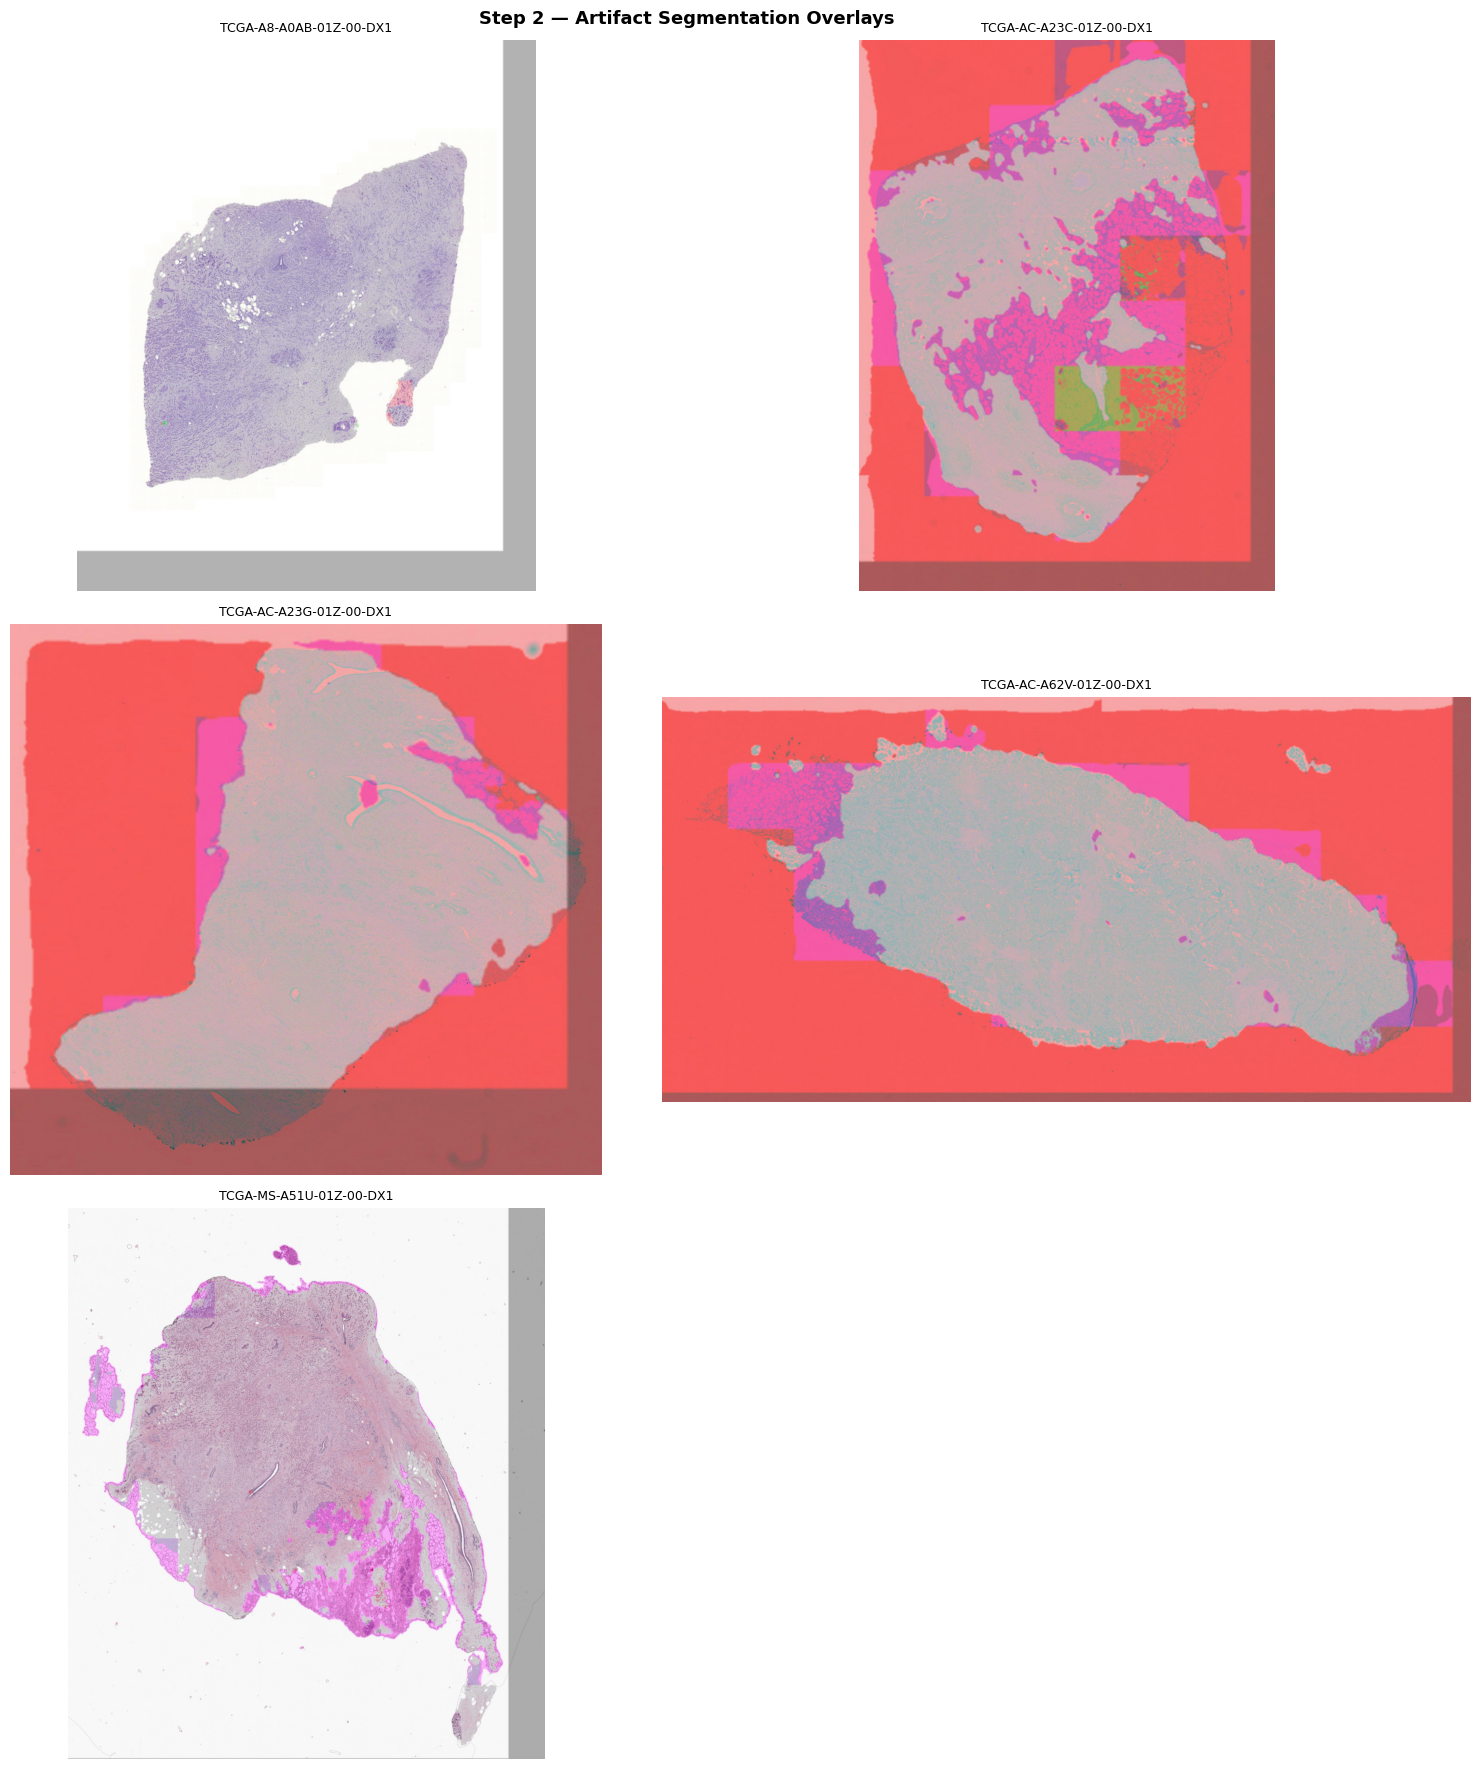

In [27]:
import matplotlib.image as mpimg

overlay_qc_dir = os.path.join(OUTPUT_DIR, "overlays_qc")
fnames_qc = sorted(os.listdir(overlay_qc_dir))

# Lay panels out 2 per row so each image is large enough to inspect
ncols = 2 if len(fnames_qc) > 1 else 1
nrows = (len(fnames_qc) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * nrows))
axes = np.array(axes).reshape(-1)

for ax, fname in zip(axes, fnames_qc):
    ax.imshow(mpimg.imread(os.path.join(overlay_qc_dir, fname)))
    ax.set_title(fname.replace("_overlay_QC.jpg", ""), fontsize=9)
    ax.axis("off")
for ax in axes[len(fnames_qc):]:   # hide unused panels in the last row
    ax.axis("off")

plt.suptitle("Step 2 — Artifact Segmentation Overlays", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 5.2 View Original Slides in IDC SLIM Viewer

The IDC SLIM viewer is a web-based pathology viewer for DICOM whole slide images. The links below open each slide at full resolution.

In [29]:
from IPython.display import IFrame, display

print("IDC SLIM viewer links (open in browser for full-resolution viewing):\n")
for _, row in demo_slides.iterrows():
    url = idc_client.get_viewer_URL(seriesInstanceUID=row["SeriesInstanceUID"])
    print(f"  {row['ContainerIdentifier']}")
    print(f"    {url}\n")

# Embed the first slide inline (750 px height)
first_url = idc_client.get_viewer_URL(seriesInstanceUID=demo_slides.iloc[0]["SeriesInstanceUID"])
print(f"Embedding: {demo_slides.iloc[0]['ContainerIdentifier']}")
display(IFrame(first_url, width="100%", height=750))

IDC SLIM viewer links (open in browser for full-resolution viewing):

  TCGA-AC-A23G-01Z-00-DX1
    https://viewer.imaging.datacommons.cancer.gov/slim/studies/2.25.50420347238962390240397469928564808838/series/1.3.6.1.4.1.5962.99.1.1231269212.1319310616.1637613841756.2.0

  TCGA-AC-A23C-01Z-00-DX1
    https://viewer.imaging.datacommons.cancer.gov/slim/studies/2.25.152145624386252553473554604280836097116/series/1.3.6.1.4.1.5962.99.1.1283257000.1868032442.1637665829544.2.0

  TCGA-AC-A62V-01Z-00-DX1
    https://viewer.imaging.datacommons.cancer.gov/slim/studies/2.25.241832143351794856972415812588470326610/series/1.3.6.1.4.1.5962.99.1.1364949850.1310426889.1637747522394.2.0

  TCGA-MS-A51U-01Z-00-DX1
    https://viewer.imaging.datacommons.cancer.gov/slim/studies/2.25.331833237758191447388107803597887857867/series/1.3.6.1.4.1.5962.99.1.1232545528.1025729098.1637615118072.2.0

  TCGA-A8-A0AB-01Z-00-DX1
    https://viewer.imaging.datacommons.cancer.gov/slim/studies/2.25.305523966109504368018

## Part 6: Validating the Pipeline Against Pre-computed TCGA Masks

Parts 3–5 ran GrandQC on IDC DICOM slides via wsidicom — a path the GrandQC authors did not test. To check our results are consistent with theirs, we compare against the pre-computed QC masks the authors published for the TCGA cohorts:

> **GrandQC pre-computed masks**: [zenodo.org/records/14041578](https://zenodo.org/records/14041578) — one tar per TCGA cohort (~18 GB total). `BRCA.tar` (~2 GB) holds masks for 1,105 **diagnostic (DX) slides**.

Each mask is a PNG named `{barcode}.{UUID}.svs_mask.png` with integer labels 1–7 (the same classes `main.py` produces). Rather than download the full 2 GB archive, we pull just the reference masks for our five demo slides (~700 KB) and compare them side by side with our local run.

### 6.1 Available Cohort Archives

The Zenodo record contains one tar file per TCGA cohort; a few large cohorts (LUAD, LUSC, THCA, TGCT) are split into two parts. The cell below lists them straight from the Zenodo API — no large download.

In [30]:
import requests

# Fetch the Zenodo record metadata to get the authoritative file list
rec = requests.get("https://zenodo.org/api/records/14041578").json()
files = rec["files"]

rows_z = []
for f in sorted(files, key=lambda x: x["key"]):
    rows_z.append({
        "archive": f["key"],
        "size_MB": round(f["size"] / 1024**2, 0),
    })

zenodo_df = pd.DataFrame(rows_z)
total_gb  = zenodo_df["size_MB"].sum() / 1024
print(f"{len(zenodo_df)} archives  |  total: {total_gb:.1f} GB\n")
display(zenodo_df)

36 archives  |  total: 17.0 GB



,archive,size_MB
0,ACC.tar,236.0
1,BLCA.tar,807.0
2,BRCA.tar,2001.0
3,CESC.tar,205.0
4,CHOL.tar,27.0
5,COADREAD.tar,587.0
6,DLBC.tar,30.0
7,ESCA.tar,129.0
8,GBM.tar,1269.0
9,HNSC.tar,347.0


### 6.2 Download the Reference Masks for Our Slides

The GrandQC authors published pre-computed artifact masks for TCGA on Zenodo
(record 14041578), one `.tar` per cohort. `BRCA.tar` (~1.95 GB) holds masks for **1,105**
TCGA-BRCA diagnostic slides — 1,104 of the 1,133 BRCA DX slides in IDC — named
`BRCA/mask_qc/<barcode>.<UUID>.svs_mask.png`.

We download the archive once and extract only our ten slides.

> **The download is resumable on purpose.** Zenodo drops long transfers; a plain
> `urlretrieve` of a 2 GB file fails partway often enough that it is not safe to rely on.
> The loop below resumes from wherever it stopped via HTTP `Range`, which Zenodo honours
> even though it does not advertise `Accept-Ranges`.


In [ ]:
# ── GrandQC reference masks (Zenodo record 14041578) ─────────────────────────
import tarfile
import time

import requests

REF_MASKS_DIR = "brca_ref_masks"
os.makedirs(REF_MASKS_DIR, exist_ok=True)
BRCA_TAR = "BRCA.tar"
BRCA_URL = "https://zenodo.org/records/14041578/files/BRCA.tar?download=1"

total = int(requests.head(BRCA_URL, allow_redirects=True, timeout=60).headers["content-length"])
for attempt in range(1, 21):
    have = os.path.getsize(BRCA_TAR) if os.path.exists(BRCA_TAR) else 0
    if have >= total:
        break
    print(f"  BRCA.tar: {have / 1024**3:5.2f} / {total / 1024**3:.2f} GB ...", flush=True)
    try:
        r = requests.get(BRCA_URL, headers={"Range": f"bytes={have}-"},
                         stream=True, timeout=(30, 120))
        if r.status_code not in (200, 206):
            print(f"    unexpected status {r.status_code}; retrying")
            time.sleep(5)
            continue
        with open(BRCA_TAR, "ab") as f:
            for chunk in r.iter_content(1 << 20):
                if chunk:
                    f.write(chunk)
    except Exception as exc:                      # noqa: BLE001 - any drop is retryable
        print(f"    connection dropped ({type(exc).__name__}); resuming")
        time.sleep(3)

size = os.path.getsize(BRCA_TAR)
assert size == total, f"BRCA.tar incomplete: {size} of {total} bytes"
print(f"  BRCA.tar complete ({size / 1024**3:.2f} GB)\n")

# Extract only the masks for our cohort.
wanted = set(demo_slides["ContainerIdentifier"])
ref_mask_by_barcode = {}
with tarfile.open(BRCA_TAR) as tf:
    for member in tf:
        if not member.name.endswith("_mask.png"):
            continue
        base = os.path.basename(member.name)
        barcode = base.split(".")[0]              # '<barcode>.<UUID>.svs_mask.png'
        if barcode in wanted:
            with tf.extractfile(member) as src, open(os.path.join(REF_MASKS_DIR, base), "wb") as dst:
                dst.write(src.read())
            ref_mask_by_barcode[barcode] = base

print(f"Extracted {len(ref_mask_by_barcode)} of {len(wanted)} reference masks:")
for bc in sorted(ref_mask_by_barcode):
    print(f"  {bc}")
absent = wanted - set(ref_mask_by_barcode)
if absent:
    print(f"\nWARNING: no reference mask for {sorted(absent)} -- excluded from Part 6.")


### 6.3 Compare Reference and Local Results Side by Side

Three panels per slide: the reference (Zenodo, computed from the original `.svs`), our
local DICOM result, and an explicit **difference** map. Two artifact maps side by side
make it hard to see *where* they disagree, so the third panel classifies every pixel:

- **red** — tissue only our run found (the reference calls it background)
- **blue** — tissue only the reference found
- **amber** — both call it tissue but assign different artifact classes

That separation matters, because a tissue-detection boundary difference and an
artifact-classification difference are very different things. Panels are cropped to the
tissue, and each row reports whole-image agreement alongside agreement *within tissue
both pipelines detected* — the number that isolates the artifact model from the
tissue-detection boundary.

GrandQC mask values are 1-based (`1`=clean tissue … `7`=background). Value `0` is the
unwritten right/bottom margin left by the floor-grid — it is not a class, so it is drawn
as background here and excluded from every metric.


In [ ]:
from matplotlib.patches import Patch
from PIL import Image

Image.MAX_IMAGE_PIXELS = None

# GrandQC palette. Mask values are 1-based; 0 is the unwritten margin, not a class.
QC_PAL = {
    1: ("#9e9e9e", "Clean tissue"),
    2: ("#ff6347", "Folds"),
    3: ("#00c853", "Dark spots"),
    4: ("#e53935", "Pen marks"),
    5: ("#ff00ff", "Bubbles/edges"),
    6: ("#4b0082", "Out-of-focus"),
    7: ("#ffffff", "Background"),
}


def qc_tissue(m):
    """Boolean tissue mask: any class except background (7) and the margin (0)."""
    return (m != 7) & (m != 0)


def qc_colorize(m):
    out = np.full(m.shape + (3,), 255, np.uint8)
    for v, (hx, _) in QC_PAL.items():
        out[m == v] = [int(hx[i:i + 2], 16) for i in (1, 3, 5)]
    out[m == 0] = 255
    return out


def qc_crop(a, b):
    """Common shape + a crop box around the tissue of either mask."""
    h, w = min(a.shape[0], b.shape[0]), min(a.shape[1], b.shape[1])
    a, b = a[:h, :w], b[:h, :w]
    ys, xs = np.where(qc_tissue(a) | qc_tissue(b))
    if len(ys) == 0:
        return a, b, (slice(0, h), slice(0, w))
    p = 40
    return a, b, (slice(max(0, ys.min() - p), min(h, ys.max() + p)),
                  slice(max(0, xs.min() - p), min(w, xs.max() + p)))


def qc_agreement(a, b):
    """(whole-image %, within-shared-tissue %) for two same-shaped masks."""
    h, w = min(a.shape[0], b.shape[0]), min(a.shape[1], b.shape[1])
    a, b = a[:h, :w], b[:h, :w]
    both = qc_tissue(a) & qc_tissue(b)
    inner = (a[both] == b[both]).mean() * 100 if both.any() else float("nan")
    return (a == b).mean() * 100, inner


def qc_compare_figure(pairs, col_titles, suptitle, subtitle=""):
    """pairs: list of (row_label, mask_A, mask_B). Renders A | B | difference."""
    fig, axes = plt.subplots(len(pairs), 3, figsize=(13.5, 3.05 * len(pairs)))
    axes = np.atleast_2d(axes)
    for r, (label, A, B) in enumerate(pairs):
        A, B, sl = qc_crop(A, B)
        at, bt = qc_tissue(A), qc_tissue(B)
        rim, lost, both = bt & ~at, at & ~bt, at & bt
        clash = both & (A != B)
        whole, inner = qc_agreement(A, B)

        diff = np.full((sl[0].stop - sl[0].start, sl[1].stop - sl[1].start, 3), 255, np.uint8)
        diff[both[sl]] = (232, 232, 232)
        diff[rim[sl]] = (255, 0, 0)
        diff[lost[sl]] = (0, 90, 255)
        diff[clash[sl]] = (255, 190, 0)

        for c, img in enumerate([qc_colorize(A[sl]), qc_colorize(B[sl]), diff]):
            ax = axes[r, c]
            ax.imshow(img, interpolation="nearest")
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0:
                ax.set_title(col_titles[c], fontsize=11, pad=8)
        axes[r, 0].set_ylabel(label, fontsize=8.5, labelpad=8)
        axes[r, 2].text(1.02, 0.5,
                        f"whole-image\n{whole:.2f}%\n\nwithin shared\ntissue\n{inner:.3f}%\n\n"
                        f"rim {rim.mean()*100:.2f}%\nclash {clash.mean()*100:.3f}%",
                        transform=axes[r, 2].transAxes, va="center", ha="left",
                        fontsize=8.5, family="monospace")

    fig.suptitle(suptitle, fontsize=14, fontweight="bold", y=0.997)
    if subtitle:
        fig.text(0.5, 0.978, subtitle, ha="center", fontsize=9.5, color="#555555")
    fig.legend(handles=[Patch(facecolor=h, edgecolor="#999999", label=n)
                        for _, (h, n) in QC_PAL.items()],
               loc="lower center", bbox_to_anchor=(0.5, 0.037), ncol=7, frameon=False,
               fontsize=9, title="Artifact classes (panels 1-2)", title_fontsize=9)
    fig.legend(handles=[
        Patch(facecolor="#e8e8e8", edgecolor="#999999", label="Both agree"),
        Patch(facecolor="#ff0000", label=f"Tissue only {col_titles[1].lower()} found"),
        Patch(facecolor="#005aff", label=f"Tissue only {col_titles[0].lower()} found"),
        Patch(facecolor="#ffbe00", label="Class disagreement in shared tissue")],
        loc="lower center", bbox_to_anchor=(0.5, 0.002), ncol=4, frameon=False,
        fontsize=9, title="Difference panel", title_fontsize=9)
    fig.tight_layout(rect=[0.015, 0.075, 0.945, 0.972])
    return fig


# Photometric interpretation predicts which slides behave differently, so label it.
def dicom_photometric(barcode):
    import pydicom
    best = None
    for f in sorted(glob.glob(os.path.join(SLIDE_DIR, barcode, "*.dcm"))):
        ds = pydicom.dcmread(f, stop_before_pixels=True)
        if "VOLUME" not in [str(v).upper() for v in getattr(ds, "ImageType", [])]:
            continue
        cols = int(getattr(ds, "TotalPixelMatrixColumns", 0) or 0)
        if best is None or cols > best[0]:
            best = (cols, str(ds.PhotometricInterpretation))
    return best[1] if best else "?"


import glob

pairs = []
for barcode in uid_to_barcode.values():
    ref_f = ref_mask_by_barcode.get(barcode)
    loc_p = os.path.join(OUTPUT_DIR, "mask_qc", f"{barcode}_mask.png")
    if not ref_f or not os.path.exists(loc_p):
        print(f"  skip {barcode} (missing mask)")
        continue
    pairs.append((f"{barcode}\n{dicom_photometric(barcode)}",
                  np.array(Image.open(os.path.join(REF_MASKS_DIR, ref_f))),
                  np.array(Image.open(loc_p))))

qc_compare_figure(
    pairs,
    ["Reference (Zenodo, from .svs)", "Your run (IDC DICOM)", "Difference"],
    "GrandQC artifact maps — Zenodo reference vs IDC DICOM pipeline",
    "Differences concentrate at the tissue-detection boundary, not in the artifact classes.",
)
plt.show()


### 6.4 Scaling to Cohort-level QC

Because each reference mask is just a small PNG, this comparison scales to an entire cohort. Downloading the full `BRCA.tar` (~2 GB) from the Zenodo record gives pre-computed masks for all 1,105 TCGA-BRCA diagnostic slides — enough to compute population-level artifact statistics **without running any inference locally**. We keep this notebook lightweight by validating on the five demo slides only; the comparison above reads one mask at a time, so it generalizes directly to the full set with constant memory.

## Part 7: Boundary-Anchored Edge Tiling (Optional Deep-Dive)

Parts 4–6 ran GrandQC exactly as published. Upstream GrandQC tiles each slide into full model patches using **floor division** and fills the leftover strip at the right and bottom edges — anything narrower than one patch — with a constant **background buffer**. That edge remainder is never shown to the model, so tissue and artifacts in the last (up to one-patch-wide) margin are reported as background.

An alternative is to **anchor** the edge patch: shift its read window back inside the slide so a *complete* patch is inferred at the boundary, then realign the prediction to the grid. This is the strategy used by the companion in-process GrandQC module; here we implement the same idea **on top of the exact Part 4 pipeline** — same wsidicom DICOM reader, same `GrandQC_MPP15` model, same MPP 1.5, same Step 1 tissue masks, same class labels — changing **only** the edge handling. Interior tiles are therefore inferred identically to Part 4; the two runs differ only along the slide edges.

Both strategies are described in detail, with code and a worked example, in [`grandqc_edge_tiling_notes.md`](grandqc_edge_tiling_notes.md).

> This part is an optional methodological deep-dive. It does **not** change the Part 4–6 results, which remain the faithful reproduction of upstream GrandQC.

### 7.1 Implement and Run the Boundary-Anchored Variant

We reuse the Part 4 **stock** artifact masks (`qc_output/mask_qc/`, from Step 2 / 4.2) unchanged for the slide interior and re-infer **only** the right/bottom edge remainder. Re-running the whole slide would let LANCZOS resizing and an independent tiling grid drift the interior away from the stock result; inheriting the interior byte-for-byte guarantees interior tiles are identical, so any difference in 7.2 is purely the edge handling.

For each edge cell, `_tile_read_origin` anchors the read window back to `extent − p_s` so a *complete* patch is inferred at the boundary (upstream drops that remainder into a background buffer). The `math.ceil` grid covers the edge column/row, and the anchored (back-shifted) prediction is realigned to its grid cell before being written over the inherited stock pixels. Masks are written to `qc_output/mask_qc_anchored/`, leaving the stock results in `qc_output/mask_qc/` intact.

> Runtime note: because only the edge band is recomputed (not the whole slide), this is much cheaper than a full Step 2 re-run; it reuses the already-loaded weights and the Part 4 stock masks.

In [25]:
# ── Boundary-anchored edge tiling ─────────────────────────────────────────────
# Re-run ONLY the artifact-segmentation stage (Part 4, Step 2) with a single
# change: the right/bottom edge remainder — which upstream GrandQC fills with a
# background buffer — is instead inferred from a boundary-anchored full patch.
# Everything else is identical to Part 4: wsidicom DICOM reading, the same
# GrandQC_MPP15 model, MPP 1.5, the Step 1 tissue masks, the per-tile tissue
# gate, and the class-label convention (argmax over channels). Interior tiles
# are therefore inferred identically to Part 4; the runs differ only at edges.
# See grandqc_edge_tiling_notes.md for the algorithm and a worked example.
import math
import sys
import torch
import segmentation_models_pytorch as smp
sys.path.insert(0, GRANDQC_SCRIPTS)   # the wsidicom-backed reader lives in the fork
from wsidicom_slide import WsiDicomSlide

MODEL_TILE_SIZE       = 512            # GrandQC model input side
MPP_MODEL             = 1.5            # artifact model resolution (matches Part 4)
BACK_CLASS            = 7              # GrandQC background class
ENCODER_MODEL         = "timm-efficientnet-b0"
ENCODER_MODEL_WEIGHTS = "imagenet"

DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {DEVICE}")

# Same artifact model Part 4 used (weights_only=False for PyTorch >= 2.6).
qc_model = torch.load(
    os.path.join(MODELS_QC, "GrandQC_MPP15.pth"),
    map_location=DEVICE,
    weights_only=False,
)
_preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER_MODEL, ENCODER_MODEL_WEIGHTS)


def _predict_tile(pil_tile):
    """GrandQC per-patch inference, identical to wsi_process.py: preprocess,
    predict, argmax over channels (no relabeling)."""
    arr = np.array(
        pil_tile.convert("RGB").resize((MODEL_TILE_SIZE, MODEL_TILE_SIZE),
                                        Image.Resampling.LANCZOS)
    )
    x = _preprocessing_fn(arr).transpose(2, 0, 1).astype("float32")
    x = torch.from_numpy(x).to(DEVICE).unsqueeze(0)
    pred = qc_model.predict(x).squeeze().cpu().numpy()
    return np.argmax(pred, axis=0).astype(np.uint8)


def _tile_read_origin(idx, p_s, extent):
    """Level-0 read start for grid cell `idx` along one axis, plus the cell's
    nominal origin. Interior cells use GrandQC's stock origin (idx*p_s, with its
    historical +1 offset for idx>0). An EDGE cell — whose full p_s window would
    run past `extent` — is anchored backwards to (extent - p_s) so a complete
    p_s window is read instead of dropped. Returns (read_start, nominal_x0)."""
    x0 = idx * p_s
    if x0 + p_s > extent:                        # edge cell -> anchor back
        return max(0, extent - p_s), x0
    return x0 + (1 if idx > 0 else 0), x0        # interior -> stock convention


def run_artifact_anchored(slide, mpp, stock_mask_png):
    """Boundary-anchored artifact mask that inherits the interior byte-for-byte
    from the Part 4.2 stock mask and re-infers ONLY the right/bottom edge
    remainder from a back-shifted full patch. Re-inferring the whole slide would
    let LANCZOS resizing and an independent grid drift the interior away from the
    stock result; inheriting it guarantees the interior tiles are identical."""
    full = np.array(Image.open(stock_mask_png)).copy()
    w_l0, h_l0 = slide.level_dimensions[0]
    p_s = int(MPP_MODEL / mpp * MODEL_TILE_SIZE)                 # native patch size

    # CEIL grid so the edge column/row is covered (stock uses floor + buffer).
    patch_n_w = max(1, math.ceil(w_l0 / p_s))
    patch_n_h = max(1, math.ceil(h_l0 / p_s))
    for he in range(patch_n_h):
        for wi in range(patch_n_w):
            x0, y0 = wi * p_s, he * p_s
            if (x0 + p_s <= w_l0) and (y0 + p_s <= h_l0):
                continue                                  # interior -> keep stock pixels
            r0, c0 = he * MODEL_TILE_SIZE, wi * MODEL_TILE_SIZE
            if r0 >= full.shape[0] or c0 >= full.shape[1]:
                continue                                  # grid cell beyond stock mask
            read_x, _ = _tile_read_origin(wi, p_s, w_l0)
            read_y, _ = _tile_read_origin(he, p_s, h_l0)
            raw = _predict_tile(slide.read_region((read_x, read_y), 0, (p_s, p_s)))

            # Realign the back-shifted (anchored) read to its grid cell; the strip
            # outside the slide stays background. off_x/off_y are 0 for interior.
            off_x = max(0, int(round((x0 - read_x) / p_s * MODEL_TILE_SIZE)))
            off_y = max(0, int(round((y0 - read_y) / p_s * MODEL_TILE_SIZE)))
            if off_x or off_y:
                aligned = np.full((MODEL_TILE_SIZE, MODEL_TILE_SIZE), BACK_CLASS, np.uint8)
                aligned[:MODEL_TILE_SIZE - off_y, :MODEL_TILE_SIZE - off_x] = raw[off_y:, off_x:]
                raw = aligned

            he_ = min(MODEL_TILE_SIZE, full.shape[0] - r0)
            wi_ = min(MODEL_TILE_SIZE, full.shape[1] - c0)
            full[r0:r0 + he_, c0:c0 + wi_] = raw[:he_, :wi_]
    return full


# Run on the demo slides; write to a separate folder so Part 4's stock masks in
# qc_output/mask_qc/ are left intact for the comparison in 7.2. The interior is
# inherited from those stock masks, so only the edge band is recomputed here.
ANCHORED_DIR = os.path.join(OUTPUT_DIR, "mask_qc_anchored")
os.makedirs(ANCHORED_DIR, exist_ok=True)

for barcode in uid_to_barcode.values():
    slide_folder = os.path.join(SLIDE_DIR, barcode)
    dcm = sorted(f for f in os.listdir(slide_folder) if f.lower().endswith(".dcm"))
    stock_png = os.path.join(OUTPUT_DIR, "mask_qc", f"{barcode}_mask.png")
    if not dcm or not os.path.exists(stock_png):
        print(f"  skip {barcode} (missing slide or stock mask)")
        continue
    slide = WsiDicomSlide(os.path.join(slide_folder, dcm[0]))
    mpp = float(slide.properties["openslide.mpp-x"])
    mask = run_artifact_anchored(slide, mpp, stock_png)
    slide.close()
    Image.fromarray(mask).save(os.path.join(ANCHORED_DIR, f"{barcode}_mask.png"))
    print(f"  {barcode}: {mask.shape[1]}×{mask.shape[0]} boundary-anchored mask written")

print(f"\nBoundary-anchored masks written to {ANCHORED_DIR}/")

### 7.2 Stock vs. Boundary-Anchored: Where They Differ

For each slide we show the stock artifact mask (left), the boundary-anchored mask (middle), and a disagreement map (right). Because interior tiles are inferred identically, disagreement is concentrated in the right/bottom edge band that the stock run fills with background. The table quantifies how many tissue/artifact pixels the anchored run recovers in that band.

The size of the effect depends on how far the slide's dimensions fall from an exact multiple of the native patch size: a slide that ends just after a patch boundary loses only a thin strip, while one that ends just before the next boundary loses a band nearly a full patch wide.

In [ ]:
from matplotlib.patches import Patch

# Stock (Part 4) vs boundary-anchored (7.1). Interior tiles are inferred
# identically, so disagreement is concentrated in the right/bottom edge band
# that the stock run fills with background.
barcodes = list(uid_to_barcode.values())
n = len(barcodes)
fig, axes = plt.subplots(n, 3, figsize=(15, 4.4 * n))
axes = np.atleast_2d(axes)

NON_BACKGROUND = [1, 2, 3, 4, 5, 6]           # clean tissue + 5 artifact classes
rows = []
for r, barcode in enumerate(barcodes):
    stock_path    = os.path.join(OUTPUT_DIR, "mask_qc", f"{barcode}_mask.png")
    anchored_path = os.path.join(ANCHORED_DIR, f"{barcode}_mask.png")
    ax_s, ax_a, ax_d = axes[r]
    for ax in (ax_s, ax_a, ax_d):
        ax.axis("off")
    if not (os.path.exists(stock_path) and os.path.exists(anchored_path)):
        ax_s.text(0.5, 0.5, f"{barcode}\nmask missing", ha="center", va="center")
        continue

    stock    = np.array(Image.open(stock_path))
    anchored = np.array(Image.open(anchored_path))
    h = min(stock.shape[0], anchored.shape[0])      # crop to common extent
    w = min(stock.shape[1], anchored.shape[1])       # (can differ by a pixel)
    stock, anchored = stock[:h, :w], anchored[:h, :w]

    ax_s.imshow(colorize(stock))
    ax_s.set_title(f"{barcode}\nStock: background-buffer edge", fontsize=9)
    ax_a.imshow(colorize(anchored))
    ax_a.set_title("Boundary-anchored edge", fontsize=9)

    diff = stock != anchored
    dimg = np.ones((h, w, 3))
    dimg[diff] = [0.85, 0.10, 0.10]
    ax_d.imshow(dimg)
    ax_d.set_title(f"Disagreement: {diff.mean() * 100:.2f}% of pixels", fontsize=9)

    recovered = int(np.sum(np.isin(stock, [0, BACK_CLASS]) & np.isin(anchored, NON_BACKGROUND)))
    tissue_anchored = int(np.sum(np.isin(anchored, NON_BACKGROUND)))
    rows.append({
        "slide":                 barcode,
        "disagree_%":            round(diff.mean() * 100, 3),
        "edge_px_recovered":     recovered,
        "recovered_%_of_tissue": round(recovered / tissue_anchored * 100, 3) if tissue_anchored else 0.0,
    })

legend_handles = [Patch(facecolor=mpl_colors[i], edgecolor="black", label=CLASS_NAMES_SHORT[i])
                  for i in range(len(CLASS_NAMES_SHORT))]
fig.legend(handles=legend_handles, loc="lower center", ncol=len(CLASS_NAMES_SHORT),
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, 0.0))
plt.suptitle("Stock vs. boundary-anchored edge tiling", fontweight="bold", fontsize=13)
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

recovery_df = pd.DataFrame(rows).set_index("slide")
print("Tissue/artifact pixels the stock run left as background that boundary")
print("anchoring recovers (concentrated in the right/bottom edge band):\n")
display(recovery_df)

### 7.3 Inspect the Recovered Edge Tissue: Real, or a Seam Artifact?

The 7.2 table counts pixels the anchored run marks as tissue/artifact where the stock run had background. That count is only meaningful if those pixels are **genuine tissue** recovered at the slide edge — not a misclassified stripe introduced by the anchored-tile realignment. Below we pull the original slide pixels under each recovered region and view them next to the recovered mask. Real dark-stained tissue on the left panel confirms the recovery is correct and the edge count is a genuine improvement; slide background, or a clean tile with a stripe along the seam, would instead point to a bug in the `off_x` / `off_y` realignment in 7.1.

In [ ]:
def inspect_recovered(barcode, pad=40):
    ref = np.array(Image.open(os.path.join(REF_MASKS_DIR, ref_mask_by_barcode[barcode])))
    loc = np.array(Image.open(os.path.join(ANCHORED_DIR, f"{barcode}_mask.png")))
    if ref.shape != loc.shape:
        ref = np.array(Image.fromarray(ref).resize(loc.shape[::-1], Image.Resampling.NEAREST))
    rec = (loc != BACK_CLASS) & (ref == BACK_CLASS)
    if not rec.any():
        print(f"{barcode}: nothing recovered"); return
    ys, xs = np.where(rec)
    y0, y1 = max(0, ys.min()-pad), ys.max()+pad
    x0, x1 = max(0, xs.min()-pad), xs.max()+pad
    slide_folder = os.path.join(SLIDE_DIR, barcode)
    dcm = sorted(f for f in os.listdir(slide_folder) if f.lower().endswith(".dcm"))[0]
    slide = WsiDicomSlide(os.path.join(slide_folder, dcm))
    s = MPP_MODEL / float(slide.properties["openslide.mpp-x"])   # mask px -> level-0 px
    rgb = slide.read_region((int(x0*s), int(y0*s)), 0,
                            (int((x1-x0)*s), int((y1-y0)*s))).convert("RGB")
    slide.close()
    fig, ax = plt.subplots(1, 2, figsize=(11, 5))
    ax[0].imshow(rgb);                            ax[0].set_title(f"{barcode}: pixels at recovered edge")
    ax[1].imshow(rec[y0:y1, x0:x1], cmap="gray"); ax[1].set_title("recovered region")
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()

for bc in ["TCGA-AC-A62V-01Z-00-DX1", "TCGA-AC-A23G-01Z-00-DX1"]:
    inspect_recovered(bc)